<a href="https://colab.research.google.com/github/Mohanaprema/ML-Projects-samples/blob/main/Customer_spent_analysis_using_Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded= files.upload()

Saving dataset.csv to dataset.csv


In [4]:
ds=pd.read_csv('dataset.csv')

In [5]:
print(ds.shape)
print(ds.describe())


(200, 5)
       CustomerID         Age  Annual Income (k$)  Spending Score
count  200.000000  200.000000          200.000000      200.000000
mean   100.500000   38.850000           60.560000       50.200000
std     57.879185   13.969007           26.264721       25.823522
min      1.000000   18.000000           15.000000        1.000000
25%     50.750000   28.750000           41.500000       34.750000
50%    100.500000   36.000000           61.500000       50.000000
75%    150.250000   49.000000           78.000000       73.000000
max    200.000000   70.000000          137.000000       99.000000


In [6]:
from sklearn import preprocessing
label_encoder= preprocessing.LabelEncoder()
ds['Gender']= label_encoder.fit_transform(ds['Gender'])
ds.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


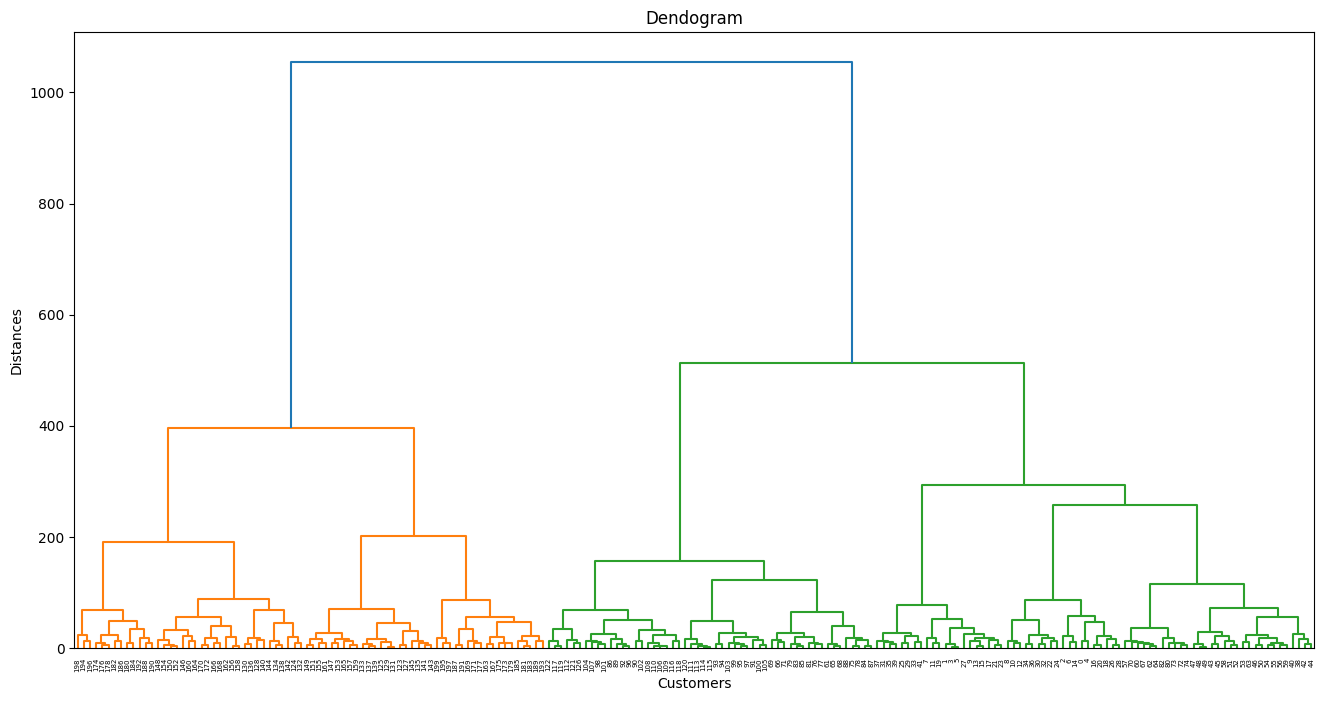

In [7]:
import scipy.cluster.hierarchy as clus
plt.figure(1,figsize=(16,8))
dendogram=clus.dendrogram(clus.linkage(ds,method='ward'))
plt.title('Dendogram')
plt.xlabel('Customers')
plt.ylabel('Distances')
plt.show()


In [19]:
from sklearn.cluster import AgglomerativeClustering
model= AgglomerativeClustering(n_clusters=5, metric='euclidean',linkage='average')
y_means=model.fit_predict(ds)
y_means

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [24]:
ds_with_cluster= pd.DataFrame(ds)
ds_with_cluster['Cluster']= y_means
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'center')
print(ds_with_cluster)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score  Cluster
0          1        1    19            15               39           3   
1          2        1    21            15               81           4   
2          3        0    20            16                6           3   
3          4        0    23            16               77           4   
4          5        0    31            17               40           3   
5          6        0    22            17               76           4   
6          7        0    35            18                6           3   
7          8        0    23            18               94           4   
8          9        1    64            19                3           3   
9         10        0    30            19               72           4   
10        11        1    67            19               14           3   
11        12        0    35            19               99           4   
12        13        0    58           

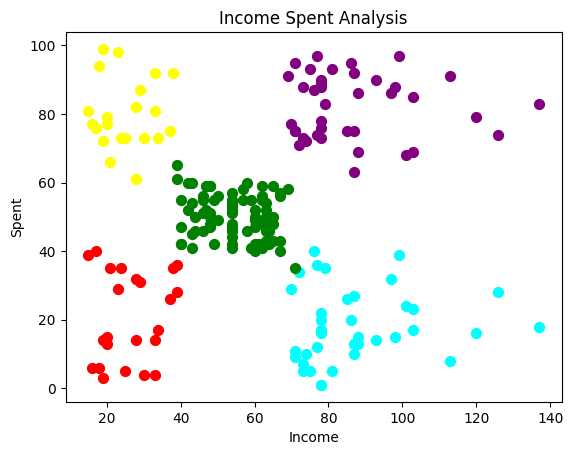

In [25]:
x= ds.iloc[:,[3,4]].values
plt.scatter(x[y_means==0,0],x[y_means==0,1], c= 'cyan',s=50, label='1')
plt.scatter(x[y_means==1,0],x[y_means==1,1], c= 'purple',s=50, label='2')
plt.scatter(x[y_means==2,0],x[y_means==2,1], c= 'green',s=50, label='3')
plt.scatter(x[y_means==3,0],x[y_means==3,1], c= 'red',s=50, label='4')
plt.scatter(x[y_means==4,0],x[y_means==4,1], c= 'yellow',s=50, label='5')
plt.title('Income Spent Analysis')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.show()
